# Evolución de una Acción con Qlib
Este notebook recupera los datos de una acción usando Qlib y muestra una gráfica de la evolución de su valor de cierre desde el 1 de enero de 2020.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import qlib
from qlib.data import D
from qlib.config import REG_US
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configurar el ticker y la fecha de inicio
TICKER = "^GSPC"  # Cambia esto por el ticker que desees analizar (ej: TSLA, MSFT, NVO, GLD)
START_DATE = "2020-01-01"

# Inicializar Qlib con los datos de mercado de US
# Nota: provider_uri debe apuntar a donde tengas descargados los datos de Qlib.
provider_uri = '~/.qlib/qlib_data/us_data'
try:
    qlib.init(provider_uri=provider_uri, region=REG_US)
    print("Qlib inicializado correctamente.")
except Exception as e:
    print(f"Aviso al inicializar Qlib: {e}")

[7579:MainThread](2026-04-10 17:38:51,857) INFO - qlib.Initialization - [config.py:453] - default_conf: client.
[7579:MainThread](2026-04-10 17:38:52,619) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[7579:MainThread](2026-04-10 17:38:52,620) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/home/toni/.qlib/qlib_data/us_data')}


Qlib inicializado correctamente.


Recuperando datos para ^GSPC desde 2020-01-01...


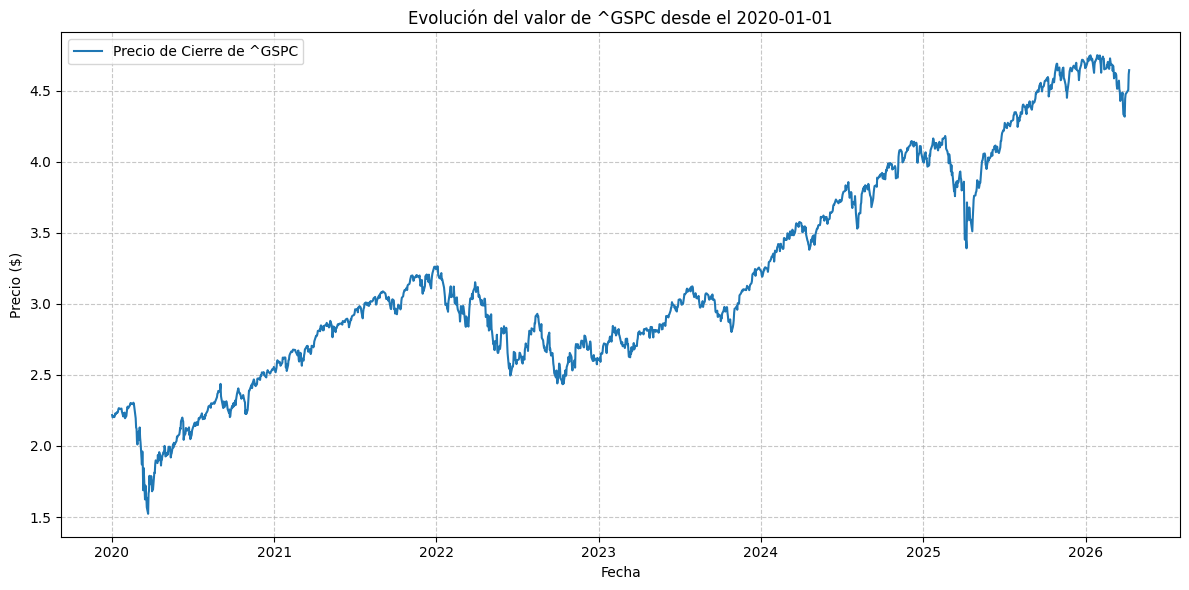

In [3]:
print(f"Recuperando datos para {TICKER} desde {START_DATE}...")

# Recuperar el precio de cierre ($close) de la acción
instruments = [TICKER]
fields = ['$close']
try:
    df = D.features(instruments, fields, start_time=START_DATE)
except Exception as e:
    print(f"Error al recuperar datos: {e}")
    df = None

if df is not None and not df.empty:
    # Qlib devuelve un DataFrame con MultiIndex (instrument, datetime).
    # Seleccionamos solo los datos del ticker especificado
    df_ticker = df.loc[TICKER]
    
    # Crear la gráfica
    plt.figure(figsize=(12, 6))
    plt.plot(df_ticker.index, df_ticker['$close'], label=f'Precio de Cierre de {TICKER}', color='#1f77b4')
    
    plt.title(f'Evolución del valor de {TICKER} desde el {START_DATE}')
    plt.xlabel('Fecha')
    plt.ylabel('Precio ($)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    plt.show()
else:
    print(f"No se encontraron datos para el ticker {TICKER} desde {START_DATE}.")

In [4]:
# Configurar pandas para mostrar todas las columnas sin ocultarlas
pd.set_option('display.max_columns', None)

# Especificar las columnas (features) que queremos traer de Qlib
instruments = [TICKER]
fields = ['$open', '$high', '$low', '$close', '$volume', '$amount', '$factor']

print(f"Recuperando todas las columnas para {TICKER}...")
df_all = D.features(instruments, fields, start_time=START_DATE)

if df_all is not None and not df_all.empty:
    # Qlib devuelve un MultiIndex, seleccionamos el ticker en cuestión
    df_ticker_all = df_all.loc[TICKER]
    
    # Extraer exactamente los últimos 40 registros
    df_40 = df_ticker_all.tail(40)
    
    print(f"Últimos 40 registros de {TICKER} con las columnas extraídas:")
    display(df_40)
else:
    print(f"No se encontraron datos para {TICKER}.")

Recuperando todas las columnas para ^GSPC...
Últimos 40 registros de ^GSPC con las columnas extraídas:


,$open,$high,$low,$close,$volume,$amount,$factor
datetime,,,,,,,
2026-02-11,4.748327,4.759898,4.704421,4.724499,9.073368e+12,NaN,0.000681
2026-02-12,4.735436,4.746109,4.644574,4.650508,1.045915e+13,NaN,0.000681
2026-02-13,4.651536,4.683995,4.624502,4.652830,8.401701e+12,NaN,0.000681
2026-02-17,4.641729,4.673807,4.611537,4.657628,7.961102e+12,NaN,0.000681
2026-02-18,4.665972,4.702481,4.662011,4.683553,7.490472e+12,NaN,0.000681
2026-02-19,4.669961,4.682062,4.650713,4.670335,7.569121e+12,NaN,0.000681
2026-02-20,4.657655,4.707068,4.652939,4.702746,7.981671e+12,NaN,0.000681
2026-02-23,4.697124,4.707817,4.641701,4.653905,8.284146e+12,NaN,0.000681
2026-02-24,4.653646,4.695709,4.638714,4.689515,7.737203e+12,NaN,0.000681


In [5]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['NVO'], ['$close', '$factor'], start_time='2026-03-01', end_time='2026-12-31')
print(df)

                          $close   $factor
instrument datetime                       
NVO        2026-03-02  46.209015  1.223756
           2026-03-03  44.862881  1.223756
           2026-03-04  47.114594  1.223756
           2026-03-05  47.812134  1.223756
           2026-03-06  47.212494  1.223756
           2026-03-09  48.681004  1.223756
           2026-03-10  47.383823  1.223756
           2026-03-11  47.518436  1.223756
           2026-03-12  46.527195  1.223756
           2026-03-13  46.453766  1.223756
           2026-03-16  47.212494  1.223756
           2026-03-17  47.028931  1.223756
           2026-03-18  45.829651  1.223756
           2026-03-19  45.376862  1.223756
           2026-03-20  44.703793  1.223756
           2026-03-23  45.058681  1.223756
           2026-03-24  45.144344  1.223756
           2026-03-25  44.459049  1.223756
           2026-03-26  44.544712  1.223756
           2026-03-27  44.104156  1.223756
           2026-03-30  44.770191  1.268637
           

In [6]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['JPM'], ['$close', '$factor'], start_time='2026-03-30', end_time='2026-12-31')
print(df)

                          $close   $factor
instrument datetime                       
JPM        2026-03-30  11.618750  0.040944
           2026-03-31  12.044161  0.040944
           2026-04-01  12.094112  0.040944
           2026-04-02  12.062176  0.040944
           2026-04-06  12.158888  0.041154
           2026-04-07  12.239137  0.041154
           2026-04-08  12.674132  0.041154
           2026-04-09  12.771255  0.041154


In [7]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['^NDX'], ['$close', '$factor'], start_time='2026-03-01', end_time='2026-12-31')
print(df)

                         $close  $factor
instrument datetime                     
^NDX       2026-03-02  6.740492  0.00027
           2026-03-03  6.666994  0.00027
           2026-03-04  6.767754  0.00027
           2026-03-05  6.747993  0.00027
           2026-03-06  6.646211  0.00027
           2026-03-09  6.733655  0.00027
           2026-03-10  6.730748  0.00027
           2026-03-11  6.733051  0.00027
           2026-03-12  6.616695  0.00027
           2026-03-13  6.575471  0.00027
           2026-03-16  6.649533  0.00027
           2026-03-17  6.683268  0.00027
           2026-03-18  6.587435  0.00027
           2026-03-19  6.568607  0.00027
           2026-03-20  6.445320  0.00027
           2026-03-23  6.523651  0.00027
           2026-03-24  6.473449  0.00027
           2026-03-25  6.516744  0.00027
           2026-03-26  6.361400  0.00027
           2026-03-27  6.238897  0.00027
           2026-03-30  6.190516  0.00027
           2026-03-31  6.402718  0.00027
           2026-

In [16]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['MSFT'], ['$close', '$factor'], start_time='2026-03-30', end_time='2026-12-31')
print(df)

                          $close   $factor
instrument datetime                       
MSFT       2026-03-30  10.089522  0.028108
           2026-03-31  10.404611  0.028108
           2026-04-01  10.382124  0.028108
           2026-04-02  10.497085  0.028108
           2026-04-06  10.480783  0.028108
           2026-04-07  10.464199  0.028108
           2026-04-08  10.521538  0.028108
           2026-04-09  10.486123  0.028108


In [17]:
df['price_adjusted'] = df['$close'] / df['$factor']

In [18]:
df

$close   $factor  price_adjusted
instrument datetime                                       
MSFT       2026-03-30  10.089522  0.028108      358.959991
           2026-03-31  10.404611  0.028108      370.170044
           2026-04-01  10.382124  0.028108      369.370026
           2026-04-02  10.497085  0.028108      373.460022
           2026-04-06  10.480783  0.028108      372.880035
           2026-04-07  10.464199  0.028108      372.290039
           2026-04-08  10.521538  0.028108      374.330017
           2026-04-09  10.486123  0.028108      373.070038